# 貓狗影像辨識 (遷移學習 ResNet18 終極版)
這份筆記本捨棄了簡單的手寫神經網路，改用微軟開發的強大 **ResNet18** 預訓練模型來進行「遷移學習」。你會發現模型的準確率會有突破性的提升！

## 1. 匯入必要的套件 (Imports)
在這個區塊，我們會匯入所有需要的程式庫。我們特別加入了 `torchvision.models` 以便等一下下載大師級的神經網路。

In [1]:
import os
import random
import time
import warnings
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tqdm.notebook import tqdm

# 忽略處理圖片時可能會出現的無害警告
warnings.filterwarnings("ignore", message="Truncated File Read")

# 判斷要使用 CPU 還是 GPU 進行訓練
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"目前使用的運算設備為: {device}")

目前使用的運算設備為: cuda


## 2. 參數與資料夾路徑設定 (Configuration)
【重要修改】：因為 ResNet18 當初是用 224x224 的圖片訓練的，我們把 `IMAGE_SIZE` 放大到 `224`。另外，因為模型已經很聰明了，我們把 `LEARNING_RATE` 調小為 `0.0001` 進行微調。

In [2]:
class Config:
    PROJECT_DIR = os.path.join(os.getcwd(), "cat_dog_classifier_notebook_run")
    DATASET_DIR = os.path.join(os.getcwd(), "cat_dog_classifier_20260411_155658", "dataset")
    MODEL_SAVE_PATH = os.path.join(PROJECT_DIR, "best_resnet_model.pth")
    
    IMAGE_SIZE = 224         # 【修改】放大為 224，發揮 ResNet 實力
    BATCH_SIZE = 32          
    LEARNING_RATE = 0.0001   # 【修改】調低學習率，只要微調就好
    NUM_EPOCHS = 10          
    EARLY_STOPPING_PATIENCE = 5 

config = Config()
os.makedirs(config.PROJECT_DIR, exist_ok=True)

print(f"將從這裡讀取圖片: {config.DATASET_DIR}")
print(f"訓練好的 ResNet 模型將儲存在: {config.MODEL_SAVE_PATH}")

將從這裡讀取圖片: c:\Users\User\OneDrive\桌面\ML_Workspace\01_Cat_Dog_CNN\cat_dog_classifier_20260411_155658\dataset
訓練好的 ResNet 模型將儲存在: c:\Users\User\OneDrive\桌面\ML_Workspace\01_Cat_Dog_CNN\cat_dog_classifier_notebook_run\best_resnet_model.pth


## 3. 定義資料集與資料擴增 (Dataset & Data Augmentation)
【重要修改】：這裡除了原本的旋轉翻轉外，加入了 `Normalize` (標準化)。這是因為當初 ResNet 在訓練時，所有的像素值都有經過這個特定的公式計算，我們必須「入境隨俗」，模型才能正常發揮。

In [3]:
class CatDogDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        self.samples = []
        self.classes = sorted(os.listdir(directory))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        for class_name in self.classes:
            class_dir = os.path.join(directory, class_name)
            if os.path.isdir(class_dir):
                for filename in os.listdir(class_dir):
                    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                        path = os.path.join(class_dir, filename)
                        label = self.class_to_idx[class_name]
                        self.samples.append((path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        try:
            image = Image.open(image_path).convert("RGB")
        except Exception as e:
            return self.__getitem__((idx + 1) % len(self))

        if self.transform:
            image = self.transform(image)
        return image, label, image_path

# ImageNet 的標準化常數
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)), 
        transforms.RandomHorizontalFlip(),                         
        transforms.RandomRotation(15),                             
        transforms.ColorJitter(brightness=0.2, contrast=0.2),      
        transforms.ToTensor(),                                     
        normalize, # 【新增】套用標準化公式
    ]),
    'val': transforms.Compose([
        transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)), 
        transforms.ToTensor(),
        normalize, # 【新增】套用標準化公式
    ])
}

train_dataset = CatDogDataset(os.path.join(config.DATASET_DIR, "train"), transform=data_transforms['train'])
val_dataset = CatDogDataset(os.path.join(config.DATASET_DIR, "val"), transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)

print(f"訓練集共有 {len(train_dataset)} 張圖片")
print(f"驗證集共有 {len(val_dataset)} 張圖片")

訓練集共有 14999 張圖片
驗證集共有 4999 張圖片


## 4. 建立神經網路架構 (Transfer Learning with ResNet18)
【重要修改】：我們直接載入 `models.resnet18`，並把原本用來分辨 1000 種東西的最後一層，拔掉換成我們專屬的 2 種輸出 (貓、狗)。這會大幅縮短訓練時間並提高準確率！

In [ ]:
# 載入已經訓練好的 ResNet18 模型 (如果電腦沒下載過，這行會稍微花點時間下載)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 取得 ResNet 最後一層輸入的特徵數量 (通常是 512)
num_ftrs = model.fc.in_features

# 把最後一層拔掉，換成我們自製的全連接層 (輸出為 2，代表貓和狗)
model.fc = nn.Sequential(
    nn.Dropout(0.5), # 這裡一樣可以加個 Dropout 稍微防止微調時過擬合
    nn.Linear(num_ftrs, 2)
)

model = model.to(device)
print("遷移學習 ResNet18 模型架構已建立！")

遷移學習 ResNet18 模型架構已建立！


## 5. 開始訓練 (Training Loop)
這部份跟之前一樣，只要觀察進度條，你會發現驗證準確率可能在前幾個 Epoch 就直接飆破 90% 甚至 95%！

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-4)

best_val_loss = float('inf')
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(config.NUM_EPOCHS):
    # ================= 1. 訓練階段 =================
    model.train() 
    running_loss, running_corrects, total_samples = 0.0, 0, 0
    
    for inputs, labels, _ in tqdm(train_loader, desc="訓練進度", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad() 
        outputs = model(inputs) 
        loss = criterion(outputs, labels) 
        loss.backward() 
        optimizer.step() 
        
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        total_samples += inputs.size(0)
        
    train_loss = running_loss / total_samples
    train_acc = running_corrects / total_samples
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ================= 2. 驗證階段 =================
    model.eval() 
    val_running_loss, val_running_corrects, val_total_samples = 0.0, 0, 0
    with torch.no_grad(): 
        for inputs, labels, _ in tqdm(val_loader, desc="驗證進度", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data).item()
            val_total_samples += inputs.size(0)
            
    val_loss = val_running_loss / val_total_samples
    val_acc = val_running_corrects / val_total_samples
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f"第 {epoch+1}/{config.NUM_EPOCHS} 回合 - "
          f"訓練損失: {train_loss:.4f}, 訓練準確率: {train_acc:.4f} | "
          f"驗證損失: {val_loss:.4f}, 驗證準確率: {val_acc:.4f}")
          
    # ================= 3. 判斷是否儲存模型與提早停止 =================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
        epochs_no_improve = 0
        print(f"  --> 驗證損失下降了！儲存最佳模型 (驗證損失: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= config.EARLY_STOPPING_PATIENCE:
            print(f"連續 {config.EARLY_STOPPING_PATIENCE} 回合沒有進步，提早停止訓練！")
            break

訓練進度:   0%|          | 0/469 [00:00<?, ?it/s]

驗證進度:   0%|          | 0/157 [00:00<?, ?it/s]

第 1/10 回合 - 訓練損失: 0.0921, 訓練準確率: 0.9631 | 驗證損失: 0.0389, 驗證準確率: 0.9864
  --> 驗證損失下降了！儲存最佳模型 (驗證損失: 0.0389)


訓練進度:   0%|          | 0/469 [00:00<?, ?it/s]

驗證進度:   0%|          | 0/157 [00:00<?, ?it/s]

...

驗證進度:   0%|          | 0/157 [00:00<?, ?it/s]

第 8/10 回合 - 訓練損失: 0.0199, 訓練準確率: 0.9930 | 驗證損失: 0.0426, 驗證準確率: 0.9854


訓練進度:   0%|          | 0/469 [00:00<?, ?it/s]

驗證進度:   0%|          | 0/157 [00:00<?, ?it/s]

第 9/10 回合 - 訓練損失: 0.0176, 訓練準確率: 0.9941 | 驗證損失: 0.0525, 驗證準確率: 0.9842
連續 5 回合沒有進步，提早停止訓練！


## 6. 評估模型與繪製 ROC 曲線
見證奇蹟的時刻！看看 ResNet18 的 ROC 曲線有多美。

正在載入最佳模型進行最終評估...


評估訓練集:   0%|          | 0/469 [00:00<?, ?it/s]

評估驗證集:   0%|          | 0/157 [00:00<?, ?it/s]

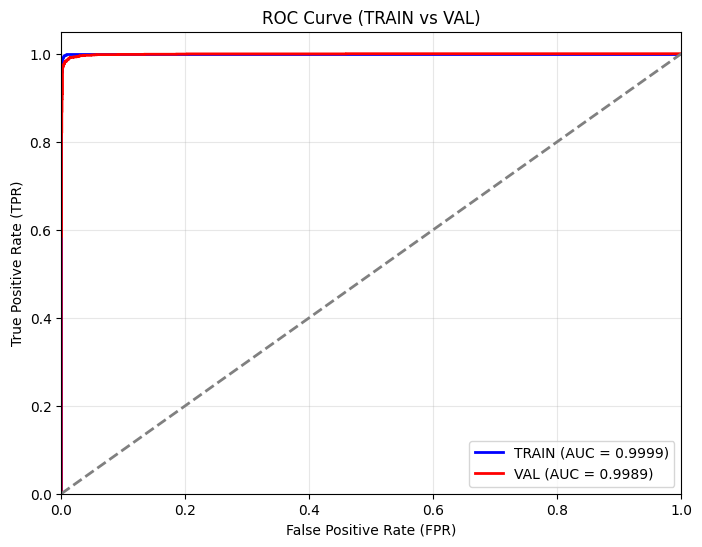

In [6]:
def evaluate_and_plot_roc(model, train_loader, val_loader, device):
    import torch.nn.functional as F
    model.eval() 
    
    def get_probs(loader, desc="正在計算機率"):
        true_labels, pred_probs = [], []
        with torch.no_grad():
            for inputs, labels, _ in tqdm(loader, desc=desc, leave=False):
                inputs = inputs.to(device)
                outputs = model(inputs)
                probs = F.softmax(outputs, dim=1)[:, 1] 
                true_labels.extend(labels.cpu().numpy())
                pred_probs.extend(probs.cpu().numpy())
        return true_labels, pred_probs

    train_true, train_probs = get_probs(train_loader, desc="評估訓練集")
    val_true, val_probs = get_probs(val_loader, desc="評估驗證集")
    
    train_fpr, train_tpr, _ = roc_curve(train_true, train_probs)
    train_auc = auc(train_fpr, train_tpr)
    
    val_fpr, val_tpr, _ = roc_curve(val_true, val_probs)
    val_auc = auc(val_fpr, val_tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(train_fpr, train_tpr, color='blue', lw=2, label=f'TRAIN (AUC = {train_auc:.4f})')
    plt.plot(val_fpr, val_tpr, color='red', lw=2, label=f'VAL (AUC = {val_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve (TRAIN vs VAL)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    plt.show()

print("正在載入最佳模型進行最終評估...")
model.load_state_dict(torch.load(config.MODEL_SAVE_PATH))
evaluate_and_plot_roc(model, train_loader, val_loader, device)